In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
df=pd.read_csv("/content/LoanApprovalPrediction.csv")

In [5]:
df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0.0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1.0,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0.0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0.0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0.0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [7]:
df.shape

(598, 13)

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 598 entries, 0 to 597
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            598 non-null    object 
 1   Gender             598 non-null    object 
 2   Married            598 non-null    object 
 3   Dependents         586 non-null    float64
 4   Education          598 non-null    object 
 5   Self_Employed      598 non-null    object 
 6   ApplicantIncome    598 non-null    int64  
 7   CoapplicantIncome  598 non-null    float64
 8   LoanAmount         577 non-null    float64
 9   Loan_Amount_Term   584 non-null    float64
 10  Credit_History     549 non-null    float64
 11  Property_Area      598 non-null    object 
 12  Loan_Status        598 non-null    object 
dtypes: float64(5), int64(1), object(7)
memory usage: 60.9+ KB


In [9]:
df.describe(include="object")

,Loan_ID,Gender,Married,Education,Self_Employed,Property_Area,Loan_Status
count,598,598,598,598,598,598,598
unique,598,2,2,2,2,3,2
top,LP002990,Male,Yes,Graduate,No,Semiurban,Y
freq,1,487,388,465,488,225,411


In [10]:
df.describe()

,Dependents,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
count,586.000000,598.000000,598.000000,577.000000,584.000000,549.000000
mean,0.755973,5292.252508,1631.499866,144.968804,341.917808,0.843352
std,1.007751,5807.265364,2953.315785,82.704182,65.205994,0.363800
min,0.000000,150.000000,0.000000,9.000000,12.000000,0.000000
25%,0.000000,2877.500000,0.000000,100.000000,360.000000,1.000000
50%,0.000000,3806.000000,1211.500000,127.000000,360.000000,1.000000
75%,1.750000,5746.000000,2324.000000,167.000000,360.000000,1.000000
max,3.000000,81000.000000,41667.000000,650.000000,480.000000,1.000000


In [11]:
df.isnull().sum()

,0
Loan_ID,0
Gender,0
Married,0
Dependents,12
Education,0
Self_Employed,0
ApplicantIncome,0
CoapplicantIncome,0
LoanAmount,21
Loan_Amount_Term,14


In [12]:
missing_percentage = (
    df.isnull().sum() / len(df) * 100
).sort_values(ascending=False)

missing_percentage

,0
Credit_History,8.193980
LoanAmount,3.511706
Loan_Amount_Term,2.341137
Dependents,2.006689
Loan_ID,0.000000
Education,0.000000
Married,0.000000
Gender,0.000000
Self_Employed,0.000000
CoapplicantIncome,0.000000


In [13]:
df.duplicated().sum()

np.int64(0)

In [14]:
df["Loan_Status"].value_counts()

,count
Loan_Status,
Y,411
N,187


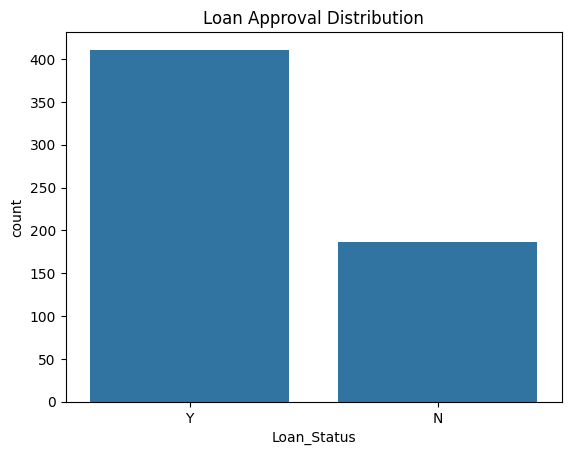

In [15]:
sns.countplot(x="Loan_Status", data=df)
plt.title("Loan Approval Distribution")
plt.show()

In [16]:
df["Loan_Status"].value_counts(normalize=True) * 100

,proportion
Loan_Status,
Y,68.729097
N,31.270903


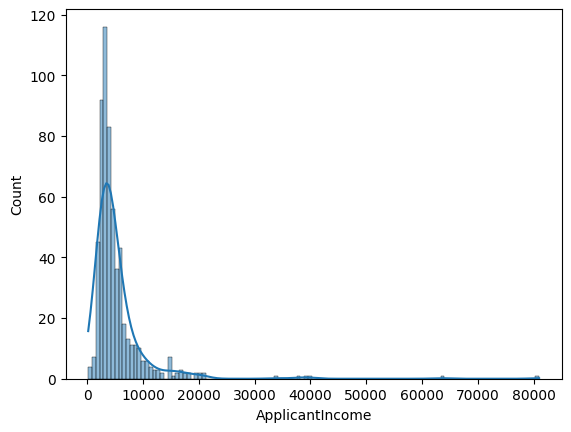

In [17]:
sns.histplot(df["ApplicantIncome"], kde=True)
plt.show()

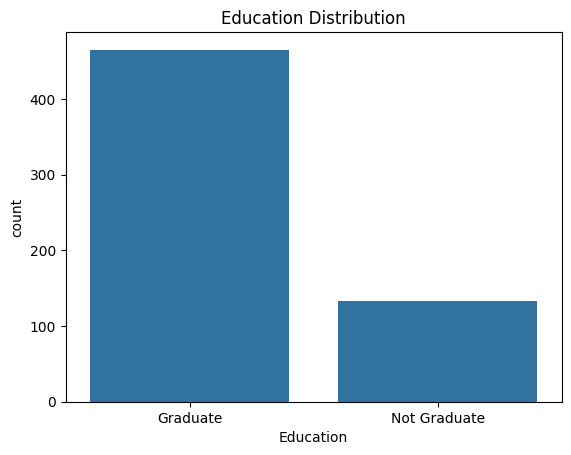

In [18]:
sns.countplot(x="Education", data=df)
plt.title("Education Distribution")
plt.show()

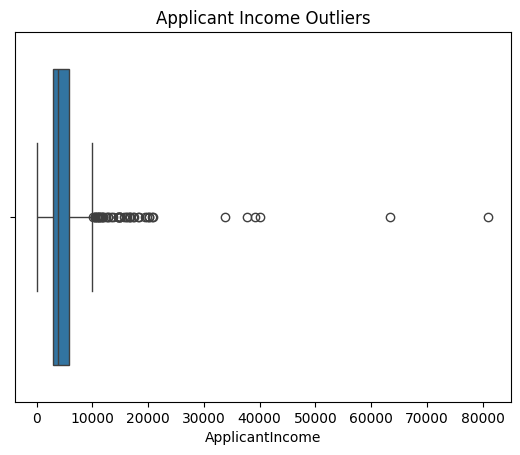

In [20]:
sns.boxplot(x=df["ApplicantIncome"])
plt.title("Applicant Income Outliers")
plt.show()

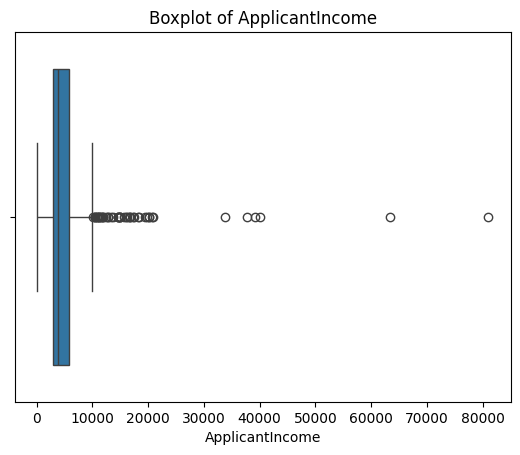

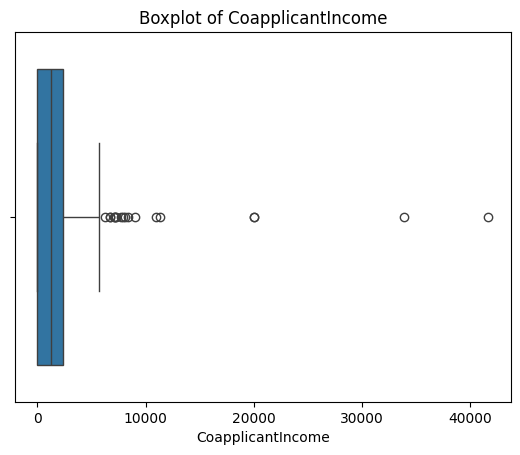

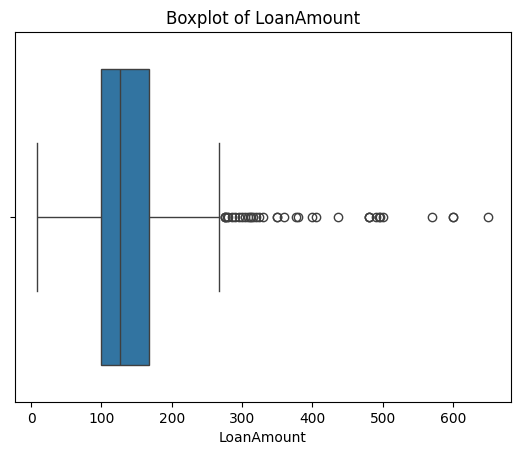

In [21]:
numeric_columns = [
    "ApplicantIncome",
    "CoapplicantIncome",
    "LoanAmount"
]

for column in numeric_columns:
    sns.boxplot(x=df[column])
    plt.title(f"Boxplot of {column}")
    plt.show()

In [22]:
Q1 = df["ApplicantIncome"].quantile(0.25)
Q3 = df["ApplicantIncome"].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

In [23]:
lower_bound

np.float64(-1425.25)

In [24]:
upper_bound

np.float64(10048.75)

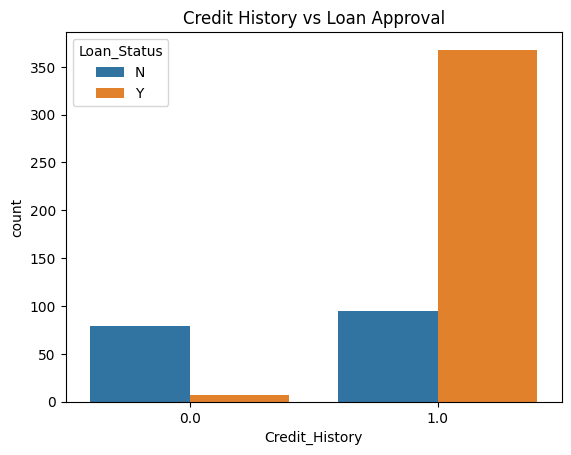

In [25]:
sns.countplot(
    x="Credit_History",
    hue="Loan_Status",
    data=df
)

plt.title("Credit History vs Loan Approval")
plt.show()

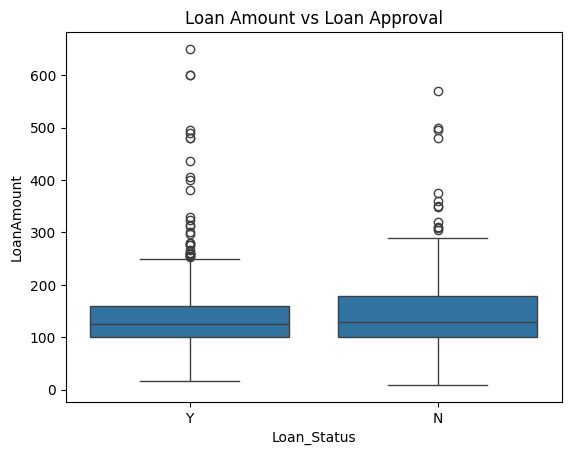

In [26]:
sns.boxplot(
    x="Loan_Status",
    y="LoanAmount",
    data=df
)

plt.title("Loan Amount vs Loan Approval")
plt.show()